# LASSO Model: Hitters Data

### Reference: http://www.science.smith.edu/~jcrouser/SDS293/labs/lab10-py.html

### Step 1 - Loading the Required Libraries and Modules¶

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import scale 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Step 2 - Reading the Data and Performing Basic Data Checks and Preparing the data

#### Description of variables in Hitters Data

A data frame with 322 observations of major league players on the following 20 variables.

AtBat: Number of times at bat in 1986

Hits: Number of hits in 1986

HmRun: Number of home runs in 1986

Runs:Number of runs in 1986

RBI: Number of runs batted in in 1986

Walks: Number of walks in 1986

Years: Number of years in the major leagues

CAtBat: Number of times at bat during his career

CHits: Number of hits during his career

CHmRun: Number of home runs during his career

CRuns: Number of runs during his career

CRBI: Number of runs batted in during his career

CWalks: Number of walks during his career

League: A factor with levels A and N indicating player's league at the end of 1986

Division: A factor with levels E and W indicating player's division at the end of 1986

PutOuts: Number of put outs in 1986

Assists: Number of assists in 1986

Errors: Number of errors in 1986

Salary: 1987 annual salary on opening day in thousands of dollars

NewLeague: A factor with levels A and N indicating player's league at the beginning of 1987

In [2]:
#read  data
Hitters = pd.read_csv('H:\My Documents\TEACHING\Financial_Data_Analytics\MS_FINANCE_REVISED\DATA\Hitters.csv')

In [3]:
#Checking the number of rows and columns
Hitters.shape

(322, 21)

In [4]:
Hitters.head()

,Name,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [5]:
df = Hitters.dropna().drop('Name', axis = 1)
df.info()
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])
df.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64

(263, 20)

In [6]:
dummies.head()

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
5,1,0,0,1,1,0


In [7]:
print(type(dummies)) 

<class 'pandas.core.frame.DataFrame'>


In [8]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


### Creating Dummy Variables for the Categorical Variables

In [9]:
y = df.Salary

# Drop the column with the independent variable (Salary), and columns for which we created dummy variables
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis = 1).astype('float64')

# Define the feature set X.
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis = 1)
 
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    float64
 1   Hits         263 non-null    float64
 2   HmRun        263 non-null    float64
 3   Runs         263 non-null    float64
 4   RBI          263 non-null    float64
 5   Walks        263 non-null    float64
 6   Years        263 non-null    float64
 7   CAtBat       263 non-null    float64
 8   CHits        263 non-null    float64
 9   CHmRun       263 non-null    float64
 10  CRuns        263 non-null    float64
 11  CRBI         263 non-null    float64
 12  CWalks       263 non-null    float64
 13  PutOuts      263 non-null    float64
 14  Assists      263 non-null    float64
 15  Errors       263 non-null    float64
 16  League_N     263 non-null    uint8  
 17  Division_W   263 non-null    uint8  
 18  NewLeague_N  263 non-null    uint8  
dtypes: float

### Step 3: Creating the Tuning Paramter: 
The LASSO() function has an alpha argument ( λ , but with a different name!) that is used to tune the model. We'll generate an array of alpha values ranging from very big to very small, essentially covering the full range of scenarios from the null model containing only the intercept, to the least squares fit:

In [10]:
alphas = 10**np.linspace(10,-2,100)*0.5
alphas

array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09, 1.23853818e+09, 9.36908711e+08, 7.08737081e+08,
       5.36133611e+08, 4.05565415e+08, 3.06795364e+08, 2.32079442e+08,
       1.75559587e+08, 1.32804389e+08, 1.00461650e+08, 7.59955541e+07,
       5.74878498e+07, 4.34874501e+07, 3.28966612e+07, 2.48851178e+07,
       1.88246790e+07, 1.42401793e+07, 1.07721735e+07, 8.14875417e+06,
       6.16423370e+06, 4.66301673e+06, 3.52740116e+06, 2.66834962e+06,
       2.01850863e+06, 1.52692775e+06, 1.15506485e+06, 8.73764200e+05,
       6.60970574e+05, 5.00000000e+05, 3.78231664e+05, 2.86118383e+05,
       2.16438064e+05, 1.63727458e+05, 1.23853818e+05, 9.36908711e+04,
       7.08737081e+04, 5.36133611e+04, 4.05565415e+04, 3.06795364e+04,
       2.32079442e+04, 1.75559587e+04, 1.32804389e+04, 1.00461650e+04,
       7.59955541e+03, 5.74878498e+03, 4.34874501e+03, 3.28966612e+03,
       2.48851178e+03, 1.88246790e+03, 1.42401793e+03, 1.07721735e+03,
      

### Step 4: Lasso coefficients with different value of alpha(lambda)
Associated with each alpha value is a vector of LASSO regression coefficients, which we'll store in a matrix coefs. In this case, it is a  100×19  matrix, with 100 rows (one for each value of alpha) and 19 columns (one for each predictors). Remember that we'll want to standardize the variables so that they are on the same scale. To do this, we can use the normalize = True parameter:

In [11]:
lasso = Lasso(normalize = True)
coefs = []

for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)
    
np.shape(coefs)

C:\Users\rashraf\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9392.589453674853, tolerance: 5331.911278864535
  model = cd_fast.enet_coordinate_descent(
C:\Users\rashraf\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5645.050125759095, tolerance: 5331.911278864535
  model = cd_fast.enet_coordinate_descent(
C:\Users\rashraf\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 20970.432027317584, tolerance: 5331.911278864535
  model = cd_fast.enet_coordinate_descent(
C:\Users\rashraf\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: Converge

(100, 19)

### We expect the coefficient estimates to be much smaller, in terms of  l2  norm, when a large value of alpha is used, as compared to when a small value of alpha is used. Let's plot and find out:

Text(0, 0.5, 'weights')

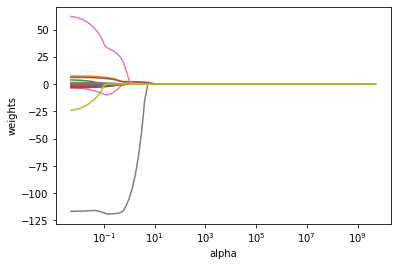

In [12]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')

### Stpe 5: Trainign and Test Data
We now split the samples into a training set and a test set in order to estimate the test error of ridge regression and the lasso:

In [13]:
# Split data into training and test sets
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

###  Step 6: Fit LASSO on Training Data and Evlauate on Test Data
Next we fit a LASSO regression model on the training set, and evaluate its MSE on the test set, using  λ=4 (arbitrary lambda) :

In [14]:
lasso2 = Lasso(alpha = 4, normalize = True)
lasso2.fit(X_train, y_train)             # Fit a lasso regression on the training data
pred2 = lasso2.predict(X_test)           # Use this model to predict the test data
print(pd.Series(lasso2.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred2))          # Calculate the test MSE

AtBat           0.000000
Hits            0.811438
HmRun           0.000000
Runs            0.000000
RBI             0.327924
Walks           2.605006
Years           0.000000
CAtBat          0.000000
CHits           0.000000
CHmRun          0.088720
CRuns           0.000000
CRBI            0.498670
CWalks          0.000000
PutOuts         0.337308
Assists         0.000000
Errors         -0.000000
League_N        0.000000
Division_W    -52.485287
NewLeague_N     0.000000
dtype: float64
107288.70675263616


### Step 7: Performance of LASSO when lambda is inifinty: Null Model
Now let's see what happens if we use a huge value of alpha: very high alpha(lambda) value will be equivalent to null model with just an intercept, resulting in higher MSE than arbitrary Lasso with lambda=4 :

In [15]:
lasso_null = Lasso(alpha = 10**10, normalize = True)
lasso_null.fit(X_train, y_train)             # Fit a LASSO regression on the training data
pred3 = lasso_null.predict(X_test)           # Use this model to predict the test data
print(pd.Series(lasso_null.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred3))          # Calculate the test MSE

AtBat          0.0
Hits           0.0
HmRun          0.0
Runs           0.0
RBI            0.0
Walks          0.0
Years          0.0
CAtBat         0.0
CHits          0.0
CHmRun         0.0
CRuns          0.0
CRBI           0.0
CWalks         0.0
PutOuts        0.0
Assists       -0.0
Errors         0.0
League_N      -0.0
Division_W    -0.0
NewLeague_N   -0.0
dtype: float64
172862.23592080915


### Step 8: LASSO with lambda=0: same as LSE
We now check whether there is any benefit to performing lasso regression with alpha = 4 instead of just performing least squares regression. Recall that least squares is simply ridge regression with alpha = 0.

In [16]:
lasso_lr = Lasso(alpha = 0, normalize = True)
lasso_lr.fit(X_train, y_train)             # Fit a ridge regression on the training data
pred = lasso_lr.predict(X_test)            # Use this model to predict the test data
print(pd.Series(lasso_lr.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred))           # Calculate the test MSE

AtBat           -1.950300
Hits             4.892086
HmRun           -4.319214
Runs            -0.449209
RBI              3.748658
Walks            3.764081
Years            8.104618
CAtBat          -0.547301
CHits            1.853960
CHmRun           2.468147
CRuns            0.449024
CRBI            -0.357194
CWalks           0.078505
PutOuts          0.422083
Assists          0.454908
Errors          -5.699950
League_N       130.208794
Division_W    -114.308297
NewLeague_N    -80.393576
dtype: float64
113692.02455792915


C:\Users\rashraf\AppData\Local\Temp/ipykernel_13204/3550815979.py:2: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  lasso_lr.fit(X_train, y_train)             # Fit a ridge regression on the training data
C:\Users\rashraf\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\rashraf\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5928766.494819721, tolerance: 3050.401923222197
  model = cd_fast.enet_coordinate_descent(


In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_test_lr= lr.predict(X_test)
print(pd.Series(lr.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test,pred_test_lr)) 
print(r2_score(y_test, pred_test_lr))

AtBat           -1.821115
Hits             4.259156
HmRun           -4.773401
Runs            -0.038760
RBI              3.984578
Walks            3.470126
Years            9.498236
CAtBat          -0.605129
CHits            2.174979
CHmRun           2.979306
CRuns            0.266356
CRBI            -0.598456
CWalks           0.171383
PutOuts          0.421063
Assists          0.464379
Errors          -6.024576
League_N       133.743163
Division_W    -113.743875
NewLeague_N    -81.927763
dtype: float64
116690.4685666114
0.32479060271955806


### Step 9: Use Cross Validation to Find the Best Lambda (alpha)

Instead of arbitrarily choosing alpha  =4 , it would be better to use cross-validation to choose the tuning parameter alpha. We can do this using the cross-validated lasso regression function, LassoCV(). By default, the function performs generalized cross-validation (an efficient form of LOOCV), though this can be changed using the argument cv.

In [18]:
lassocv = LassoCV(alphas = alphas, cv = 10, max_iter = 100000, normalize = True)
lassocv.fit(X_train, y_train)
print(lassocv.alpha_) # the best lambda (alpha)


lasso4 = Lasso(alpha = lassocv.alpha_, normalize = True) # using the best lambda (alpha)
lasso4.fit(X_train, y_train)
mean_squared_error(y_test, lasso4.predict(X_test))

2.320794416806386


104904.36377748138

#### Therefore, we see that the value of alpha that results in the smallest cross-validation error is 2.403. This represents a further improvement over the test MSE that we got using alpha =4 .  

### Step 10: Using the Best Lambda Refit the Model in Full Sample
Finally, we refit our lasso regression model on the full data set, using the value of alpha chosen by cross-validation, and examine the coefficient estimates.

In [19]:
lasso4.fit(X, y)
# Some of the coefficients are now reduced to exactly zero.

coef =pd.Series(lasso4.coef_, index=X.columns)

print(coef)

AtBat           0.000000
Hits            1.691374
HmRun           0.000000
Runs            0.000000
RBI             0.000000
Walks           1.969103
Years           0.000000
CAtBat          0.000000
CHits           0.000000
CHmRun          0.000000
CRuns           0.185938
CRBI            0.385169
CWalks          0.000000
PutOuts         0.166493
Assists        -0.000000
Errors         -0.000000
League_N        0.000000
Division_W    -65.731248
NewLeague_N     0.000000
dtype: float64


In [20]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 6 variables and eliminated the other 13 variables
